In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1.Handle Missing Values

In [8]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


# Feature Engineering

In [11]:
#Age
df["age"] = 2026 - df["Year_Birth"]

In [13]:
#Customer Joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
referance_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (referance_date - df["Dt_Customer"]).dt.days

In [14]:
#Total spendings of a customer
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [15]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [16]:
#Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Master":"Graduate",
    "PhD":"Postgraduate","Graduation":"Postgraduate"
})

In [19]:
#Living Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

# Drop Columns

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [23]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [24]:
df_cleaned.shape

(2240, 15)

# Outliers

In [25]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='object')

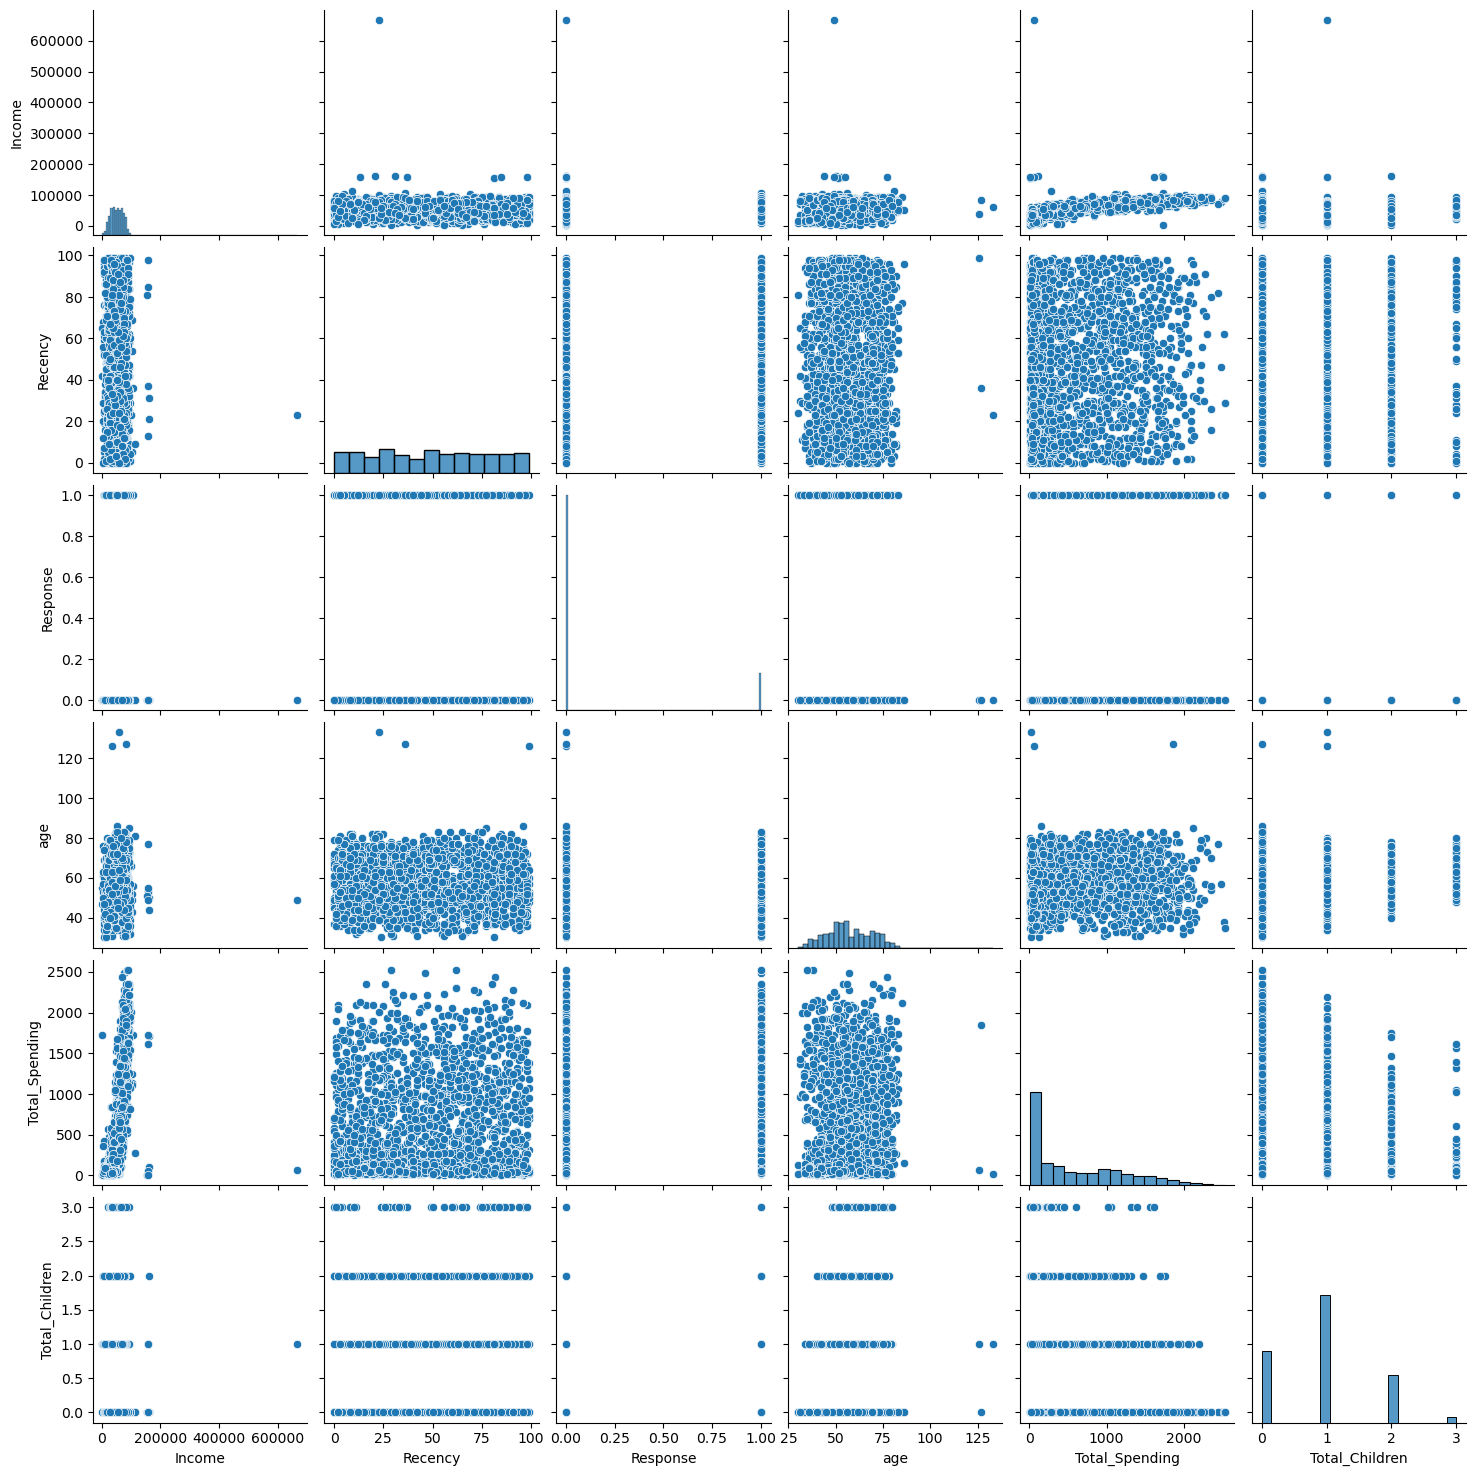

In [28]:
cols = ["Income","Recency","Response","age","Total_Spending","Total_Children"]

#relative plots of some features - pair plot
sns.pairplot(df_cleaned[cols])

In [30]:
# remove outliers

print("data size with outliers : ",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size after removing outliers : ",len(df_cleaned))


data size with outliers :  2240
data size after removing outliers :  2236


# Heatmap

<Axes: >

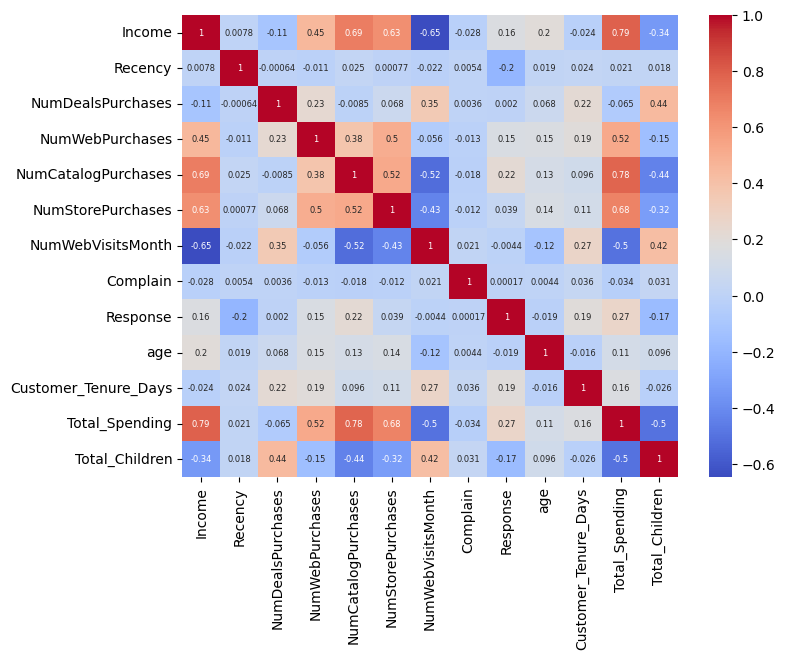

In [36]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [37]:
df_cleaned.shape

(2236, 15)

In [38]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Postgraduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Postgraduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Postgraduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Postgraduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [39]:
from sklearn.preprocessing import OneHotEncoder

In [40]:
ohe = OneHotEncoder()

In [41]:
cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [42]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [45]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [46]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [47]:
df_encoded.shape

(2236, 18)

# Scaling

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_encoded

X_scaled = scaler.fit_transform(X)

# Visualize : PCA

In [49]:
from sklearn.decomposition import PCA

In [50]:
pca = PCA(n_components=3)

In [51]:
x_pca = pca.fit_transform(X_scaled)

In [55]:
pca.explained_variance_ratio_

array([0.23200912, 0.11419304, 0.10454922])

Text(0.5, 0.92, '3D PCA Projection')

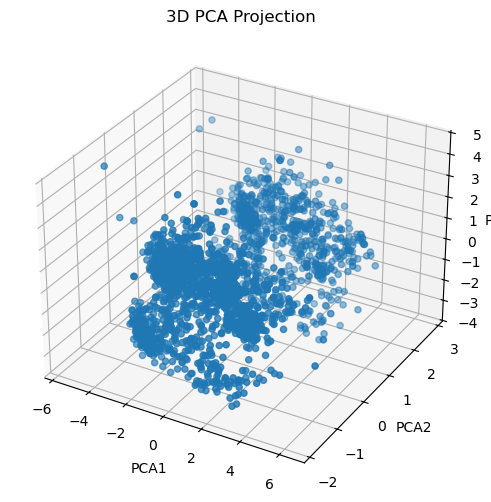

In [58]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D PCA Projection")

# Analyze K values - 1.Elbow method

In [61]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)    

In [62]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [63]:
print("k value provided by elbow method is : ",knee.knee)

k value provided by elbow method is :  4


Text(0, 0.5, 'WCSS')

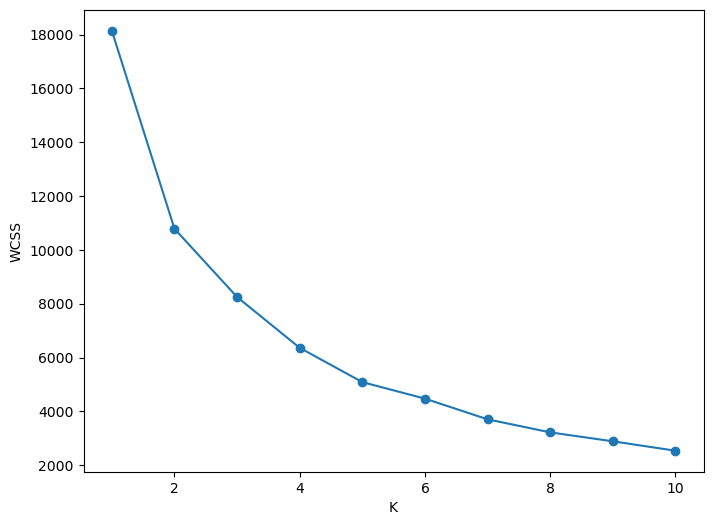

In [64]:
plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

# Analyze K values - 2.Silhoutte Score

In [70]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'SS')

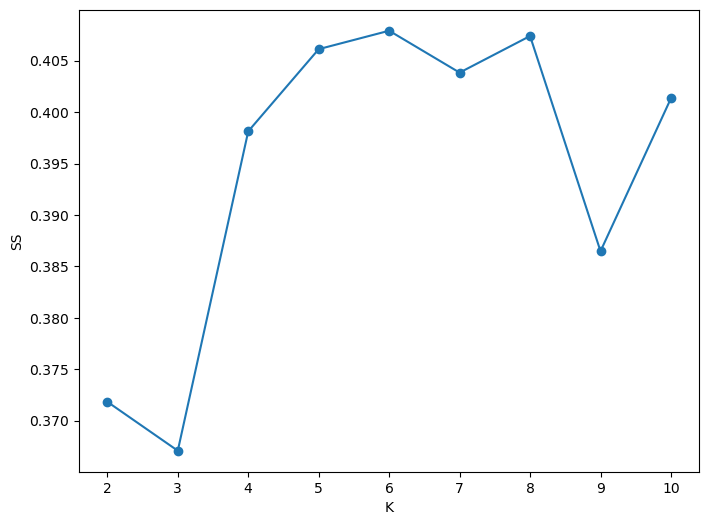

In [71]:
plt.figure(figsize=(8,6))
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("SS")

Text(0, 0.5, 'WCSS')

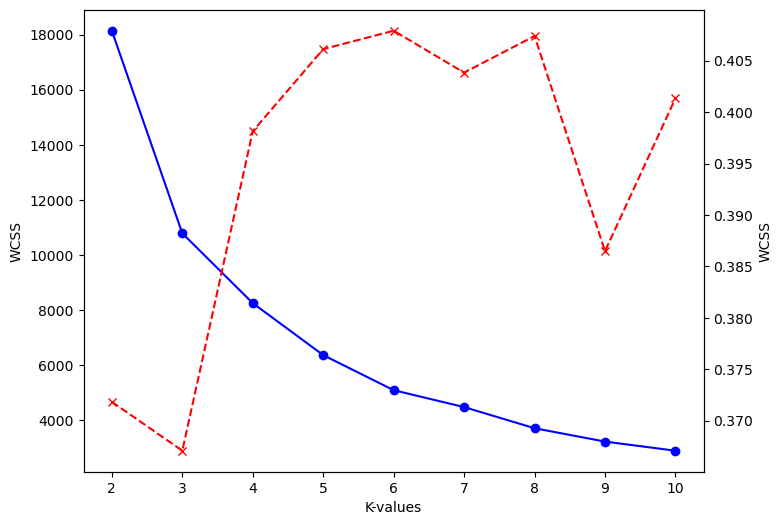

In [81]:
k_range = range(2,11)

fig , ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],color="blue",marker="o")
ax1.set_xlabel("K-values")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],color="red",marker="x",linestyle="--")
ax2.set_xlabel("K-values")
ax2.set_ylabel("WCSS")

# Clustering

In [82]:
#kmeans

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

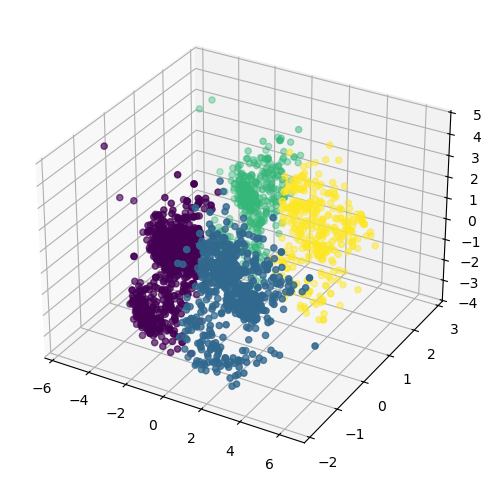

In [86]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [97]:
# Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")

labels_agg = agg_clf.fit_predict(x_pca)

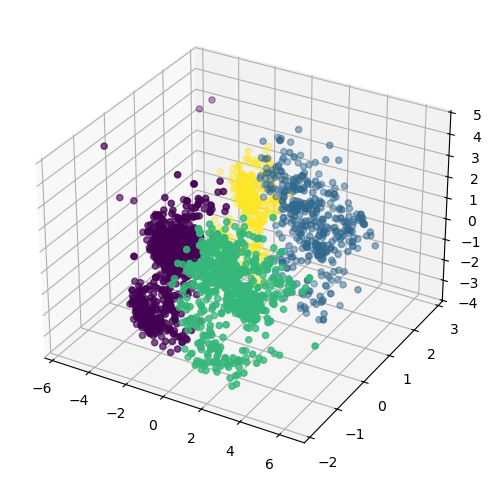

In [98]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_agg)

# Characterization of clustering - done here is Income v/s TotalSpendings

In [113]:
X["clusters"] = labels_agg

In [100]:
X.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,clusters
0,Postgraduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,1
1,Postgraduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,3
2,Postgraduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,2
3,Postgraduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='clusters', ylabel='count'>

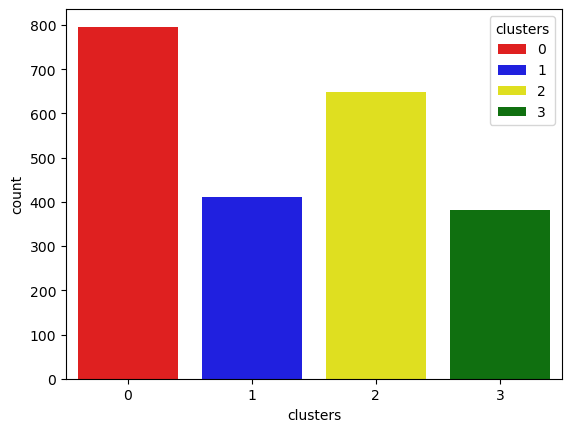

In [114]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

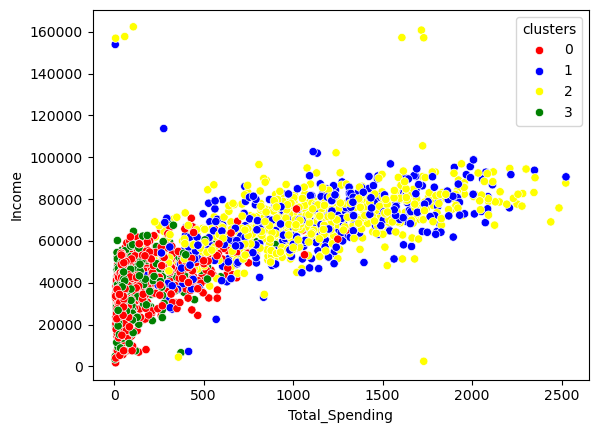

In [115]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["clusters"], palette=pal)

# Cluster Summary

In [117]:
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         36873.342337  48.913317           2.611809         2.788945   
1         67444.529197  49.221411           2.274939         5.761557   
2         70163.145833  49.239198           2.100309         5.666667   
3         35772.820210  49.217848           2.167979         2.309711   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.752513           3.709799           6.604271  0.008794   
1                    4.586375           8.075426           4.214112  0.007299   
2                    4.961420           8.367284           3.797840  0.009259   
3                    0.671916           3.320210           6.412073  0.010499   

          Response        age  Customer_Tenure_Days  Total_Spending  \
clu